In [1]:
import pandas as pd

In [2]:
splits = {
    "train": "data/train-00000-of-00001.parquet",
    "test": "data/test-00000-of-00001.parquet",
}
df = pd.read_parquet("hf://datasets/nlile/hendrycks-MATH-benchmark/" + splits["train"])

/home/kartikag234/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = df.drop(columns=["unique_id"])

# Map levels to difficulty
def difficulty(level):
    if level in [1, 2]:   return "Easy"
    elif level == 3:       return "Medium"
    else:                  return "Hard"  # levels 4 & 5

df["difficulty"] = df["level"].apply(difficulty)

# Count per subject × difficulty
result = (
    df.groupby(["subject", "difficulty"])
      .size()
      .unstack(fill_value=0)
      [["Easy", "Medium", "Hard"]]  # enforce column order
)

print(result.to_string())

difficulty              Easy  Medium  Hard
subject                                   
Algebra                  816     627  1364
Counting & Probability   300     256   651
Geometry                 251     225   833
Intermediate Algebra     386     477  1238
Number Theory            285     297   765
Prealgebra               692     458   844
Precalculus              380     279   576


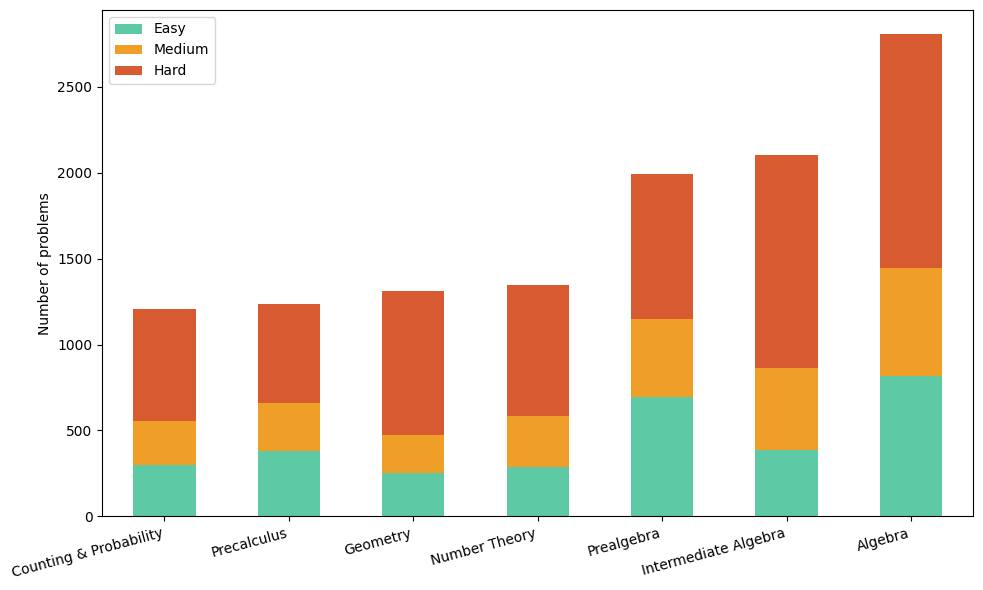

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "subject":  ["Algebra", "Counting & Probability", "Geometry",
                 "Intermediate Algebra", "Number Theory", "Prealgebra", "Precalculus"],
    "Easy":   [816, 300, 251, 386, 285, 692, 380],
    "Medium": [627, 256, 225, 477, 297, 458, 279],
    "Hard":   [1364, 651, 833, 1238, 765, 844, 576],
}

df = pd.DataFrame(data).set_index("subject")
df["total"] = df.sum(axis=1)
df = df.sort_values("total").drop(columns="total")  # ascending by total

ax = df.plot(
    kind="bar", stacked=True, figsize=(10, 6),
    color=["#5DCAA5", "#EF9F27", "#D85A30"]
)
ax.set_xlabel("")
ax.set_ylabel("Number of problems")
ax.set_xticklabels(df.index, rotation=15, ha="right")
plt.tight_layout()
plt.savefig("math_difficulty_sorted.png", dpi=150)
plt.show()